In [1]:
pip install miditok


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 159.0/159.0 kB 15.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 78.0 MB/s eta 0:00:00


In [2]:
pip install torch

In [3]:
pip install music21

In [4]:
pip install librosa pydub midi2audio IPython


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 124.3 MB/s eta 0:00:00


In [ ]:
import os
os.environ["XLA_MODEL_PARALLEL"] = "1"

In [8]:
import torch

In [ ]:
from torch_xla.distributed.parallel_loader import MpDeviceLoader

In [ ]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="torch.utils.data.dataloader")


In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [10]:
from miditok import REMI, TokenizerConfig
from miditok.utils import split_files_for_training
from miditok.pytorch_data import DatasetMIDI, DataCollator
from torch.utils.data import DataLoader
from pathlib import Path

from miditok import REMI
tokenizer = REMI(params="/content/MIDI-LSTM-and-transformer-decoder/trained_tokenizer/tokenizer_final.json")


/usr/local/lib/python3.12/dist-packages/miditok/tokenizations/remi.py:88: UserWarning: Attribute controls are not compatible with 'config.one_token_stream_for_programs' and multi-vocabulary tokenizers. Disabling them from the config.
  super().__init__(tokenizer_config, params)


In [11]:
tokenizer.vocab_size


5000

In [12]:
import zipfile
import os

def extract_datasets(zip_path,extract_path):
  with zipfile.ZipFile(zip_path, 'r') as zip_ref:
      erro = zip_ref.testzip()
      return zip_ref.extractall(extract_path)

In [13]:
training_unziped = extract_datasets("/content/MIDI-LSTM-and-transformer-decoder/features/dataset_training.zip","/content/dataset_training")

test_unziped = extract_datasets("/content/MIDI-LSTM-and-transformer-decoder/features/dataset_test.zip","/content/dataset_test")

validation_unziped = extract_datasets("/content/MIDI-LSTM-and-transformer-decoder/features/dataset_validation.zip","/content/dataset_validation")


In [15]:
training_path = list(Path("/content/dataset_training").glob("**/*.mid"))
validation_path = list(Path("/content/dataset_validation").glob("**/*.mid"))
test_path = list(Path("/content/dataset_test").glob("**/*.mid"))


In [16]:
print(len(training_path))
print(len(validation_path))
print(len(test_path))

15175
5951
2678


In [17]:
dataset_chunks_dir = Path("/content/training_chunked")

In [31]:
max_seq_len = 512
batch_size = 64
hidden_dim = 64
epochs = 15
embed_dim = 32
num_layers = 1
name_model = "pesos_lstm.pt"
version=1
complete_path = f"/content/MIDI-LSTM-and-transformer-decoder/training/tokenizer_novo/{version}/"

In [19]:
# Split MIDIs into smaller chunks for training
split_files_for_training(
    files_paths=training_path,
    tokenizer=tokenizer,
    save_dir=dataset_chunks_dir,
    max_seq_len=max_seq_len,
)
print(split_files_for_training) #512, 1024, or 2048 tokens

Splitting music files (/content/training_chunked): 100%|██████████| 15175/15175 [00:35<00:00, 430.49it/s]

<function split_files_for_training at 0x7fc04beef1a0>


In [20]:
dataset_training = DatasetMIDI(
    files_paths=list(dataset_chunks_dir.glob("**/*.mid")),
    tokenizer=tokenizer,
    max_seq_len=max_seq_len,
    bos_token_id=tokenizer["BOS_None"],
    eos_token_id=tokenizer["EOS_None"],
)
print(dataset_training)

68777 files.


In [21]:
dataset_validation = DatasetMIDI(
    files_paths=validation_path,
    tokenizer=tokenizer,
    max_seq_len=max_seq_len,
    bos_token_id=tokenizer["BOS_None"],
    eos_token_id=tokenizer["EOS_None"],
)
print(dataset_validation)

5951 files.


In [22]:
dataset_test = DatasetMIDI(
    files_paths=test_path,
    tokenizer=tokenizer,
    max_seq_len=max_seq_len,
    bos_token_id=tokenizer["BOS_None"],
    eos_token_id=tokenizer["EOS_None"],
)
print(dataset_test)

2678 files.


In [23]:
collator = DataCollator(tokenizer.pad_token_id, copy_inputs_as_labels=True, shift_labels=True)


In [24]:
dataloader_validation = DataLoader(dataset_validation, batch_size=batch_size,num_workers=0, persistent_workers=False, collate_fn=collator,drop_last=True)

dataloader_test = DataLoader(dataset_test, batch_size=60, collate_fn=collator)

In [25]:
import random

def generate_sample_input_predict(dataloader_test):
  valor=random.randint(1, len(dataloader_test))
  counter = 1
  for batch in dataloader_test:
    if counter == valor:
      return batch["input_ids"]
    counter=counter+1

In [46]:
import torch
import torch.nn as nn

class MusicGeneratorLSTM(nn.Module):
    def __init__(self, vocab_size,embed_dim,hidden_dim,num_layers):
        super().__init__()
        self.num_layers = num_layers
        self.hidden_dim = hidden_dim
        self.embedding = nn.Embedding(vocab_size,embed_dim)
        self.lstm = nn.LSTM(input_size=embed_dim, hidden_size=hidden_dim, num_layers=num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x, hidden=None):
        if hidden is None:
            batch_size = x.size(0)
            device = x.device
            hidden = (
                torch.zeros(self.num_layers, batch_size, self.hidden_dim, device=device),
                torch.zeros(self.num_layers, batch_size, self.hidden_dim, device=device)
            )

        x = self.embedding(x)
        out, hidden = self.lstm(x, hidden)
        out = self.fc(out)
        return out, hidden

In [27]:
from pathlib import Path

def converte_output_to_midi(lstm_output, name):
  lstm_output.dump_midi(Path(f"{name}.mid"))


In [28]:
from music21 import converter

def tonal_estimator(music):
  score = converter.parse(music)
  key = score.analyze("key")

  print(key)
  print(f"Tônica: {key.tonic.name} e modo: {key.mode}")
  print(f"Consistência tonal: {key.correlationCoefficient}")
  print(f"Melhor tonalidade: {key.tonalCertainty()}")

In [74]:
from collections import defaultdict
import matplotlib.pyplot as plt
import librosa

def counter_notes(music):
  counter_bar = defaultdict(int)
  counter_pitch = defaultdict(int)
  counter_velocity = defaultdict(int)

  for token in music:
    if "bar" in token.lower():
      counter_bar["bar"] += 1
    #altura das notas
    if "velocity" in token.lower():
      velocity = int(token.split("_")[1])
      counter_velocity[velocity] += 1
    # Quando encontra um Pitch (Note On)
    elif "pitch" in token.lower():
        pitch_val = int(token.split("_")[1])
        pitch_note = librosa.midi_to_note(pitch_val)
        counter_pitch[pitch_note] += 1

  plt.figure(figsize=(20, 10))
  majors_pitch = sorted(counter_pitch.items(), key=lambda x: x[1], reverse=True)
  majors_velocity = sorted(counter_velocity.items(), key=lambda x: x[1], reverse=True)

  x_pitch,y_pitch = zip(*majors_pitch)
  plt.bar(x_pitch,y_pitch, color='skyblue')

  plt.title('Notas mais tocadas')
  plt.xlabel('Notas')
  plt.ylabel('Quantidade')

  plt.show()
  print("\n \n \n")
  x_vel,y_vel = zip(*majors_velocity)
  plt.bar(x_vel,y_vel, color='skyblue')

  plt.title('Altura mais tocadas')
  plt.xlabel('Altura')
  plt.ylabel('Quantidade')

  plt.show()

  print("\n \n \n")

  print(f"Quantidade compassos: {counter_bar["bar"]}")


In [ ]:
dataloader_training = DataLoader(
  dataset_training,
  batch_size=batch_size,
  num_workers=4,
  pin_memory=False,
  persistent_workers=True,
  prefetch_factor=4,
  collate_fn=collator,
  drop_last=True
)
model = MusicGeneratorLSTM(vocab_size=tokenizer.vocab_size, embed_dim=embed_dim, hidden_dim=hidden_dim, num_layers=num_layers).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters())

list_epoch_loss = []
list_perplexity = []
print(f"Tamanho do lote de treinamento: {len(dataloader_training)}",flush=True)
print(f"Tamanho da época: {epochs}",flush=True)

Path(complete_path).mkdir(parents=True, exist_ok=True)

for epoch in range(epochs):
    loss_valores_cpu = []

    # Reinicializa o estado oculto no começo de cada época
    hidden_train = (
        torch.zeros(num_layers, batch_size, hidden_dim, device=device),
        torch.zeros(num_layers, batch_size, hidden_dim, device=device)
    )

    cont = 0
    for batch in dataloader_training:
        optimizer.zero_grad()
        if isinstance(hidden_train, tuple):
            hidden_train = (hidden_train[0].detach(), hidden_train[1].detach())

        inputs = batch["input_ids"].to(device)
        targets = batch["labels"].to(device)

        outputs, hidden_train = model(inputs, hidden_train)
        loss = criterion(outputs.reshape(-1, tokenizer.vocab_size), targets.reshape(-1))
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        loss_valores_cpu.append(loss.item())
        cont += 1
        print(f"Lote processado: {cont}", flush=True)

    loss_final = sum(loss_valores_cpu) / len(loss_valores_cpu) if loss_valores_cpu else 0.0
    perplexity = torch.exp(torch.tensor(loss_final)).item()

    list_epoch_loss.append(loss_final)
    list_perplexity.append(perplexity)

    print(f"contador total de lotes: {cont}", flush=True)
    print(f"Finalizando época: {epoch} de treinamento com loss: {loss_final:.4f}", flush=True)
    print(f"Finalizando época: {epoch} de treinamento com perplexidade: {perplexity:.4f}", flush=True)
checkpoint = {
    'model_state_dict': model.state_dict(),
    'train_loss': list_epoch_loss,
    'train_perplexity': list_perplexity
}
xm.save(checkpoint, str(Path(complete_path) / name_model))


Streaming output truncated to the last 5000 lines.
Lote processado: 386
Lote processado: 387
Lote processado: 388
Lote processado: 389
Lote processado: 390
Lote processado: 391
Lote processado: 392
Lote processado: 393
Lote processado: 394
Lote processado: 395
Lote processado: 396
Lote processado: 397
Lote processado: 398
Lote processado: 399
Lote processado: 400
Lote processado: 401
Lote processado: 402
Lote processado: 403
Lote processado: 404
Lote processado: 405
Lote processado: 406
Lote processado: 407
Lote processado: 408
Lote processado: 409
Lote processado: 410
Lote processado: 411
Lote processado: 412
Lote processado: 413
Lote processado: 414
Lote processado: 415
Lote processado: 416
Lote processado: 417
Lote processado: 418
Lote processado: 419
Lote processado: 420
Lote processado: 421
Lote processado: 422
Lote processado: 423
Lote processado: 424
Lote processado: 425
Lote processado: 426
Lote processado: 427
Lote processado: 428
Lote processado: 429
Lote processado: 430
Lote

NameError: name 'xm' is not defined

In [34]:
torch.save(checkpoint, str(Path(complete_path) / name_model))

In [35]:
path_model = f"{complete_path}{name_model}"

path_music = f"{complete_path}music-{version}"

In [ ]:
xmp.spawn(
    treinar_na_tpu,
    args=(dataset_training, collator, batch_size,hidden_dim, embed_dim,num_layers, epochs, complete_path, name_model),
    nprocs=1,
    start_method='fork'
)

Tamanho do lote de treinamento: 477
Tamanho da época: 15


/usr/local/lib/python3.12/dist-packages/jax/_src/cloud_tpu_init.py:86: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(


Lote processado: 1


In [ ]:
device_test = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [47]:
path_model = f"{complete_path}{name_model}"
model_t_v = MusicGeneratorLSTM(vocab_size=tokenizer.vocab_size, embed_dim=embed_dim, hidden_dim=hidden_dim, num_layers=num_layers)
state_dict = torch.load(path_model,map_location=device)
res = model_t_v.load_state_dict(state_dict['model_state_dict'], strict=True)
loss_training = state_dict['train_loss']
perplexity_training = state_dict['train_perplexity']
print(res)
model_t_v.to(device)
model_t_v.eval()


<All keys matched successfully>


MusicGeneratorLSTM(
  (embedding): Embedding(5000, 32)
  (lstm): LSTM(32, 64, batch_first=True)
  (fc): Linear(in_features=64, out_features=5000, bias=True)
)

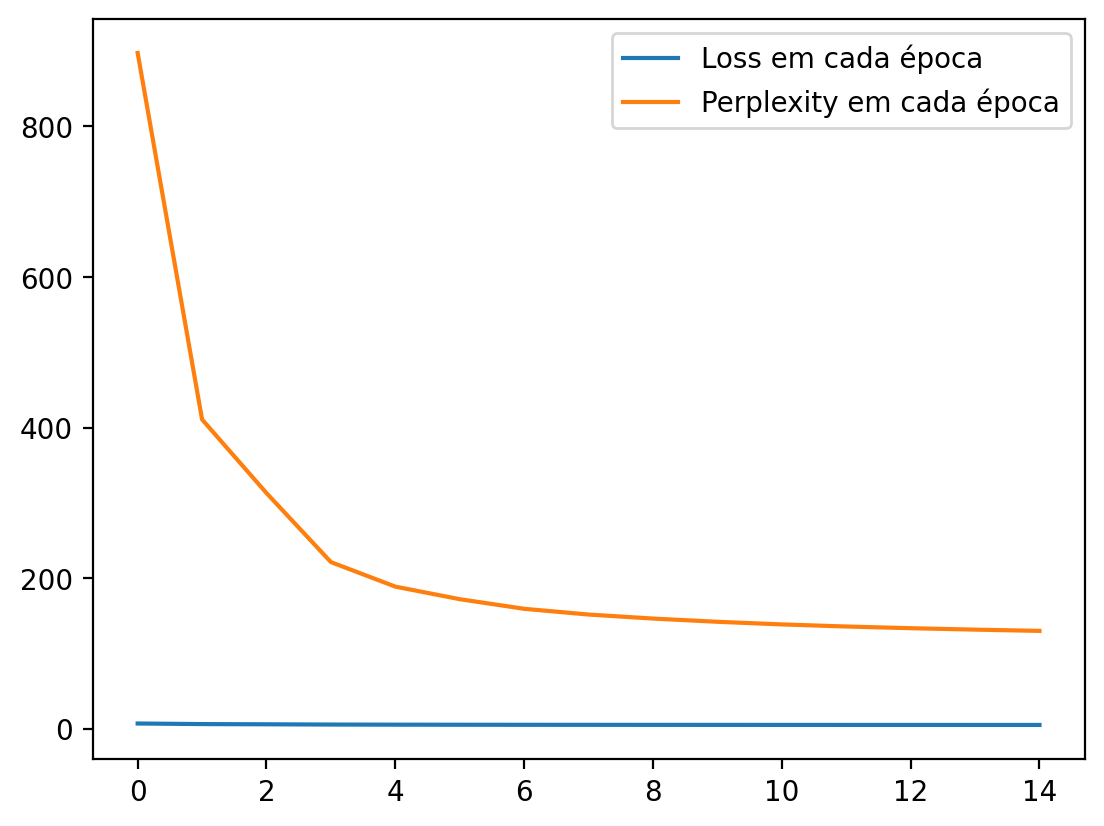

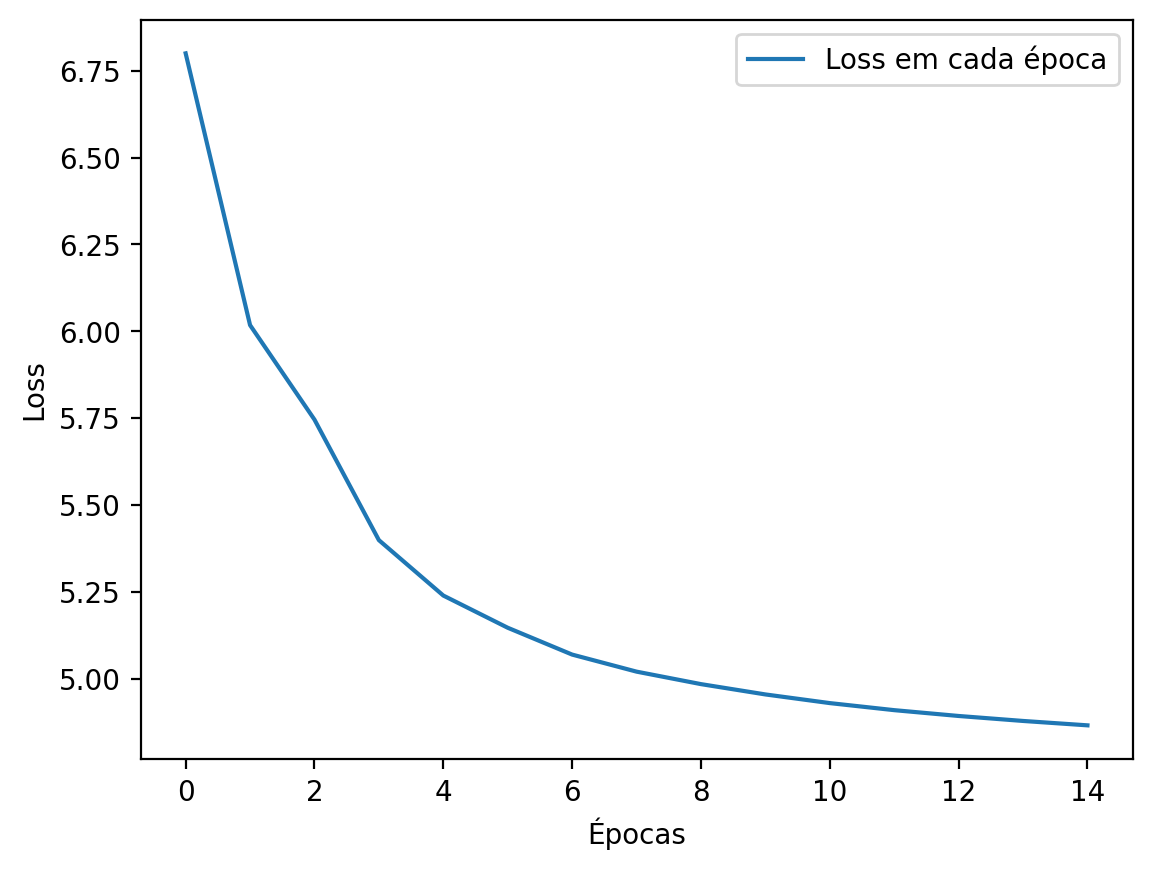

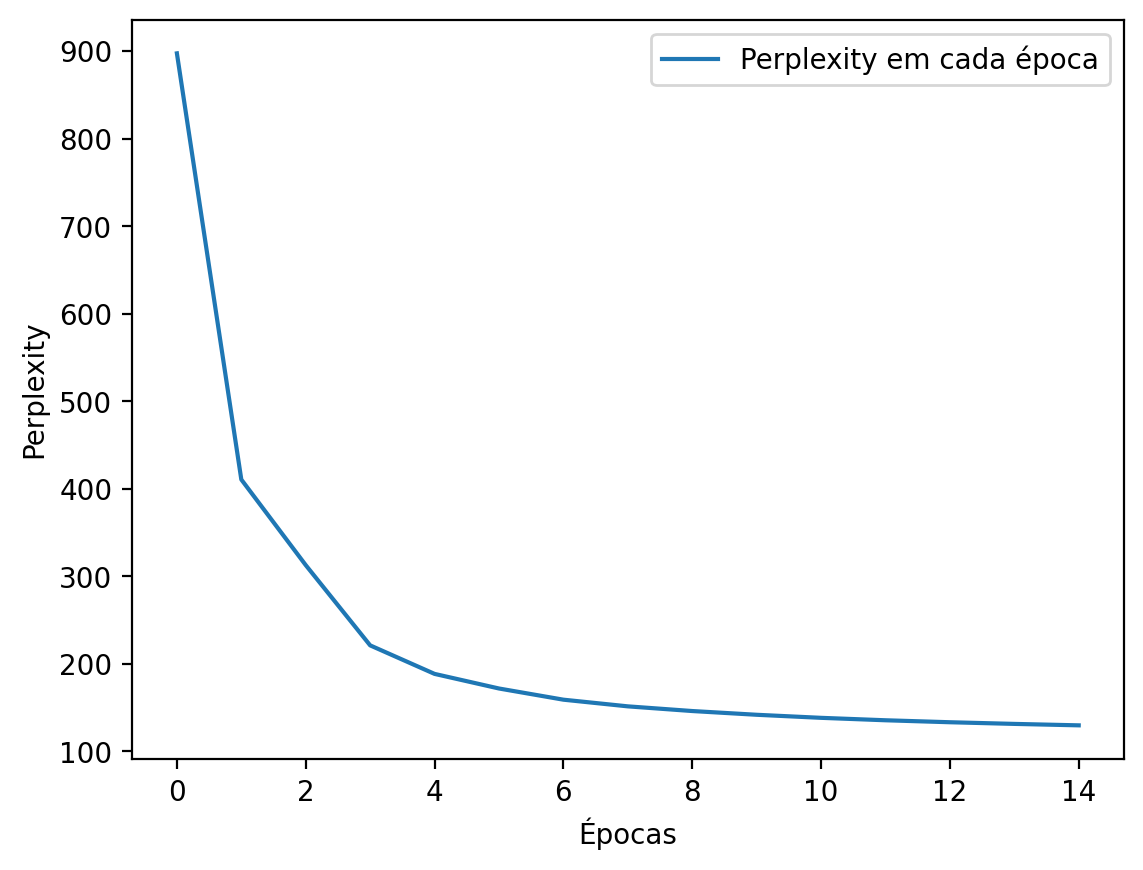

In [39]:
import matplotlib.pyplot as plt
lista_epochs = [i for i in range(epochs)]

# Plota cada lista com um rótulo (label)
plt.plot(lista_epochs, loss_training, label='Loss em cada época')
plt.plot(lista_epochs, perplexity_training, label='Perplexity em cada época')


# Adiciona título, legenda e exibe
plt.legend()
plt.show()

print("\n \n \n")

# Plota cada lista com um rótulo (label)
plt.plot(lista_epochs, loss_training, label='Loss em cada época')


# Adiciona título, legenda e exibe
plt.legend()
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.show()

print("\n \n \n")
# Plota cada lista com um rótulo (label)
plt.plot(lista_epochs, perplexity_training, label='Perplexity em cada época')


# Adiciona título, legenda e exibe
plt.legend()
plt.xlabel('Épocas')
plt.ylabel('Perplexity')
plt.show()


In [49]:
total_loss = 0.0
ac = 0.0
criterion = nn.CrossEntropyLoss()
batch_len = 0
with torch.no_grad():
    hidden_validation = None
    for batch in dataloader_validation:
        if hidden_validation is not None:
            hidden_validation = (hidden_validation[0].detach(), hidden_validation[1].detach())
        inputs = batch["input_ids"].to(device)
        targets = batch["labels"].to(device)

        outputs, hidden_validation = model_t_v(inputs, hidden_validation)
        target_reshaped = targets.reshape(-1)
        loss = criterion(outputs.reshape(-1, tokenizer.vocab_size), target_reshaped)
        total_loss += loss.item()
        predicted = outputs.argmax(dim=-1).reshape(-1)
        ac += ((predicted==target_reshaped).sum().item()) / target_reshaped.size(0)

mean_loss = total_loss / len(dataloader_validation)
print(f"Perda média na validação: {mean_loss}")

mean_loss_tensor = torch.tensor(mean_loss)

perplexity_validation = torch.exp(mean_loss_tensor)
print(f"Perplexidade na validação: {perplexity_validation.item()}")

perplexity_validation = torch.exp(mean_loss_tensor)
print(f"Acurácia na validação: {ac}")

Perda média na validação: 4.8977862441021465
Perplexidade na validação: 133.99281311035156
Acurácia na validação: 3.064605088648463


In [56]:
def make_prediction(model, dataloader_test, steps=0):
  inputs = generate_sample_input_predict(dataloader_test)
  hidden = None
  for _ in range(steps):
    with torch.no_grad():
      outputs, hidden = model(inputs.to(device), hidden)
      next_token_tensor = outputs[:, -1, :].argmax(-1,keepdim=True)
      inputs = torch.cat([inputs.to(device), next_token_tensor],dim=1)
  return inputs[0]



In [58]:
music_predicted = make_prediction(model_t_v, dataloader_test, steps=100)
music_predicted = music_predicted.squeeze().tolist()

In [59]:
music_decoded = tokenizer(music_predicted)
print(music_decoded)

Score(ttype=Tick, tpq=8, begin=0, end=1417, tracks=1, notes=588, time_sig=1, key_sig=0, markers=0)


In [61]:
music_to_midi = converte_output_to_midi(music_decoded, path_music)
print(music_decoded)

Score(ttype=Tick, tpq=8, begin=0, end=1417, tracks=1, notes=588, time_sig=1, key_sig=0, markers=0)


In [60]:
midi = tokenizer(music_decoded)
print(midi)

TokSequence(tokens=['Bar_None', 'TimeSig_4/4', 'Position_0', 'Tempo_121.29', 'Position_18', 'Program_0', 'Pitch_74', 'Velocity_75', 'Duration_1.6.8', 'Program_0', 'Pitch_70', 'Velocity_75', 'Duration_1.5.8', 'Bar_None', 'TimeSig_4/4', 'Position_0', 'Program_0', 'Pitch_39', 'Velocity_55', 'Duration_3.2.8', 'Position_2', 'Program_0', 'Pitch_73', 'Velocity_75', 'Duration_1.4.8', 'Program_0', 'Pitch_69', 'Velocity_59', 'Duration_1.4.8', 'Position_8', 'Program_0', 'Pitch_49', 'Velocity_67', 'Duration_2.1.8', 'Position_14', 'Program_0', 'Pitch_69', 'Velocity_71', 'Duration_1.4.8', 'Program_0', 'Pitch_73', 'Velocity_75', 'Duration_1.4.8', 'Program_0', 'Pitch_55', 'Velocity_71', 'Duration_1.3.8', 'Position_20', 'Program_0', 'Pitch_61', 'Velocity_71', 'Duration_2.4.8', 'Position_24', 'Program_0', 'Pitch_72', 'Velocity_71', 'Duration_0.2.8', 'Program_0', 'Pitch_68', 'Velocity_67', 'Duration_0.1.8', 'Position_26', 'Program_0', 'Pitch_73', 'Velocity_67', 'Duration_1.6.8', 'Program_0', 'Pitch_68', 

In [62]:
tonal_estimator(f"{path_music}.mid")

g minor
Tônica: G e modo: minor
Consistência tonal: 0.806173469087755
Melhor tonalidade: 0.8877864705525395


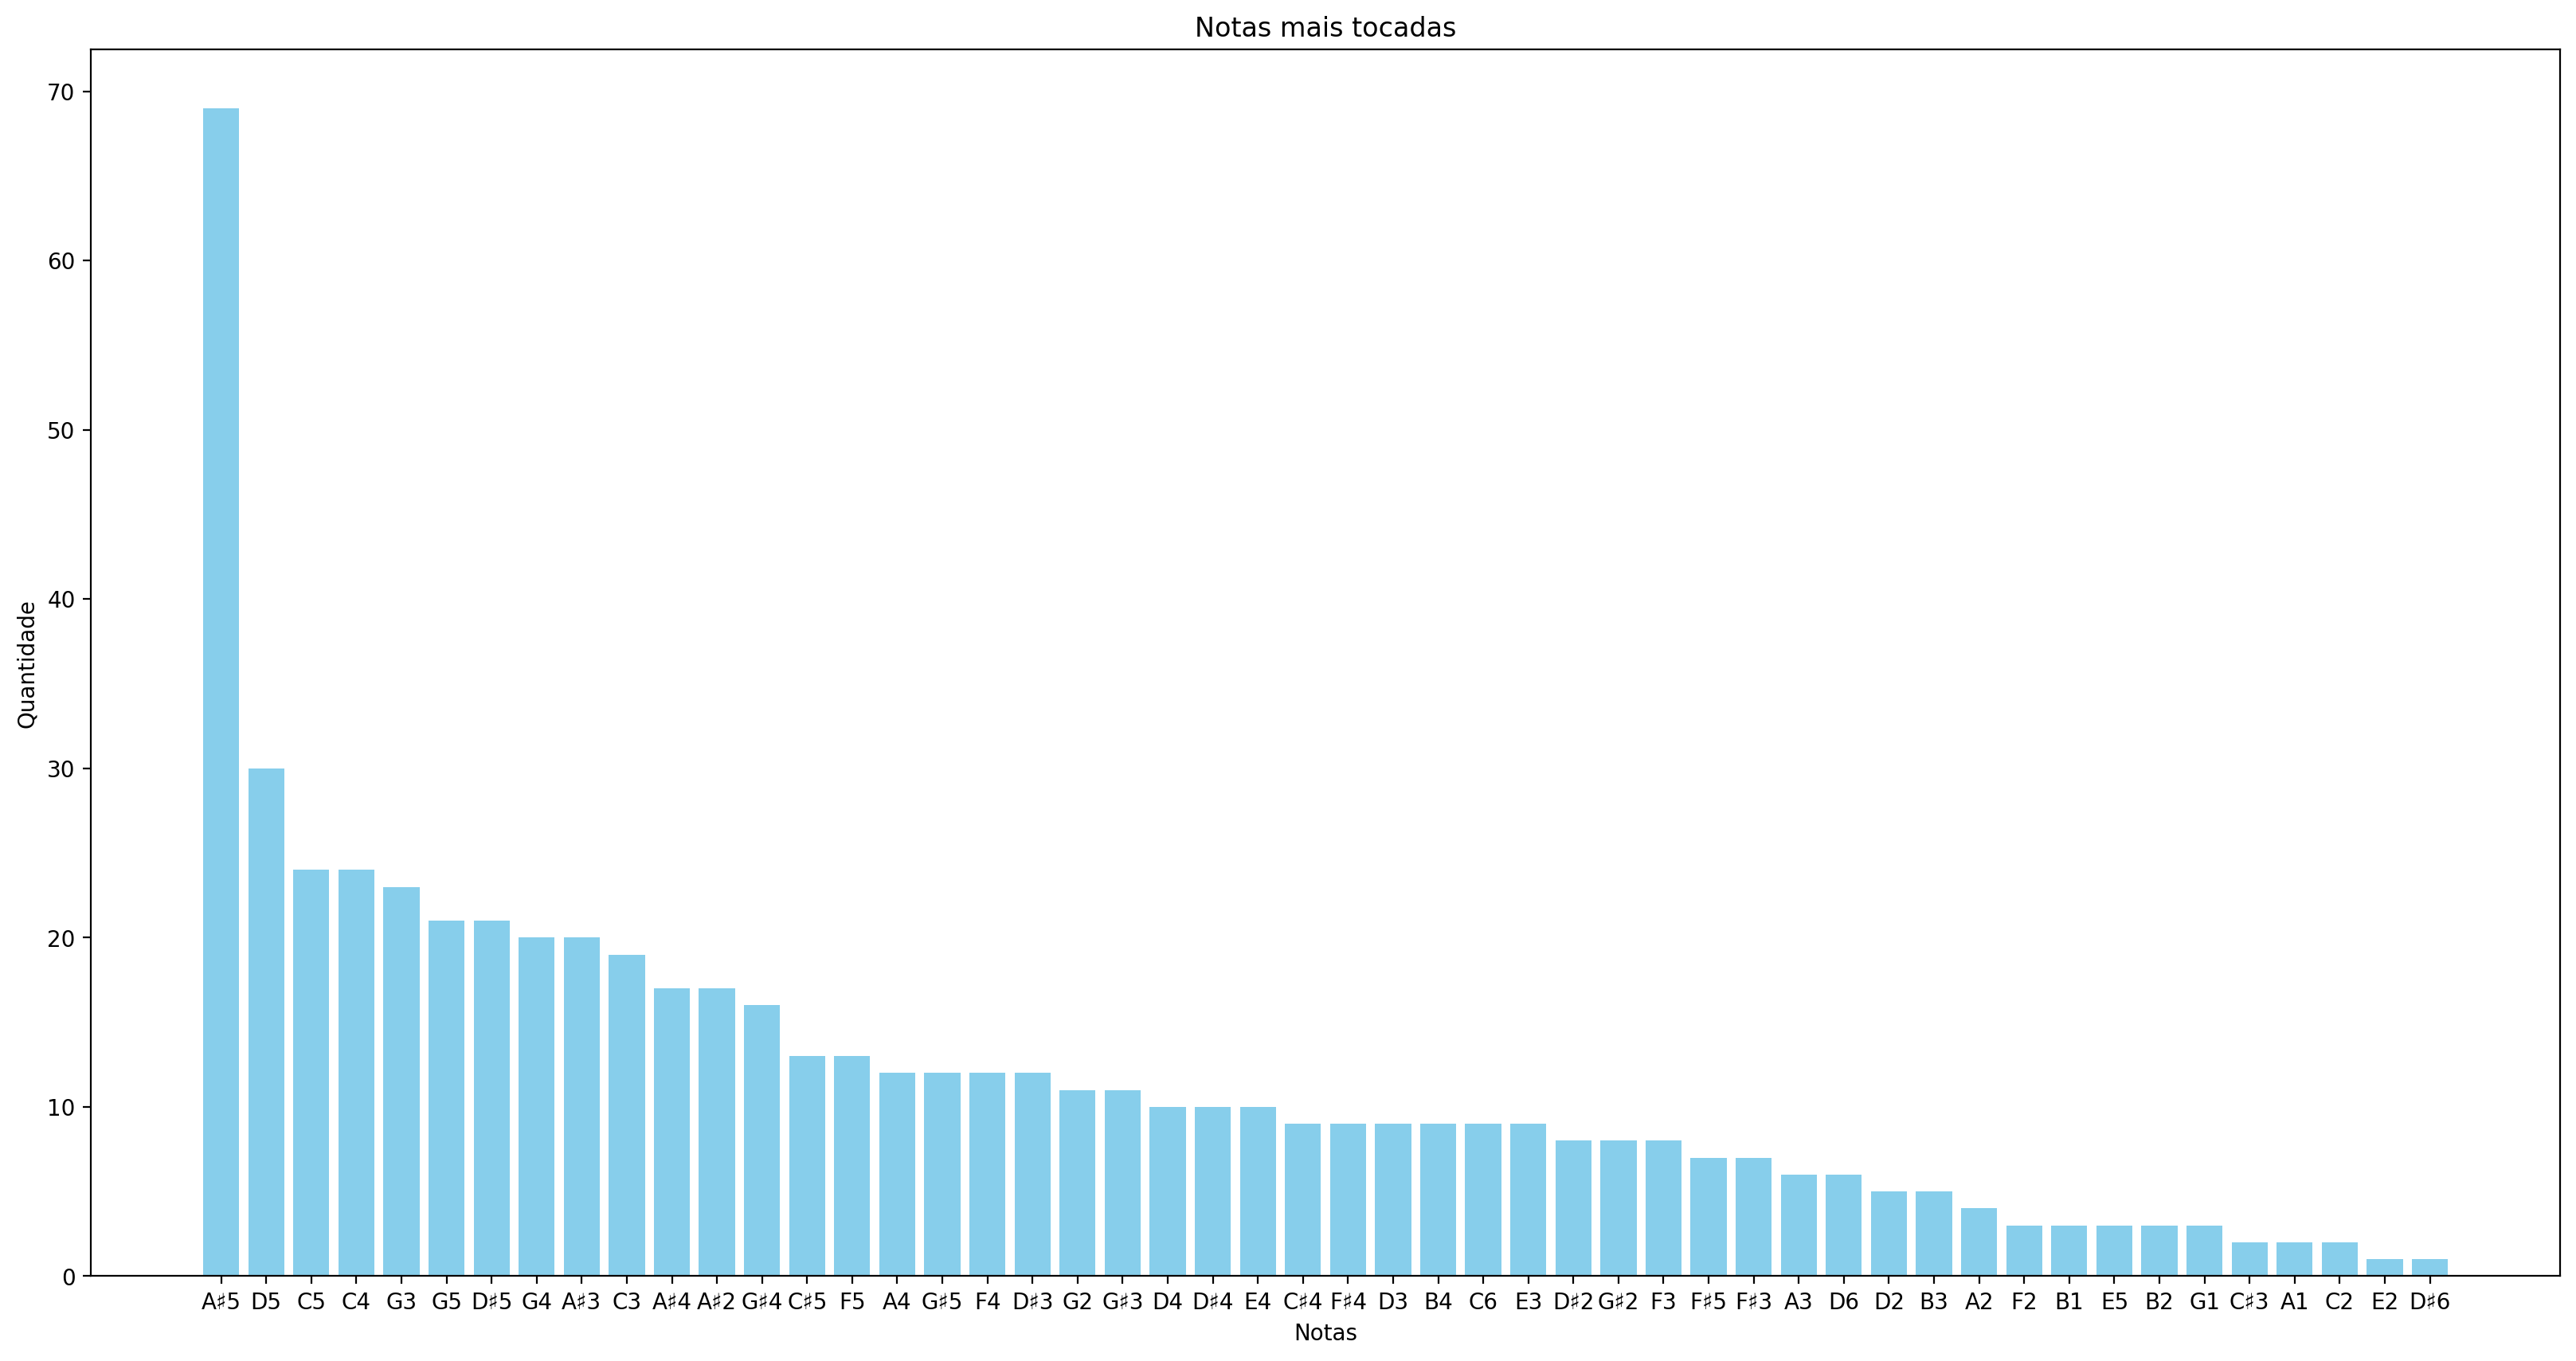

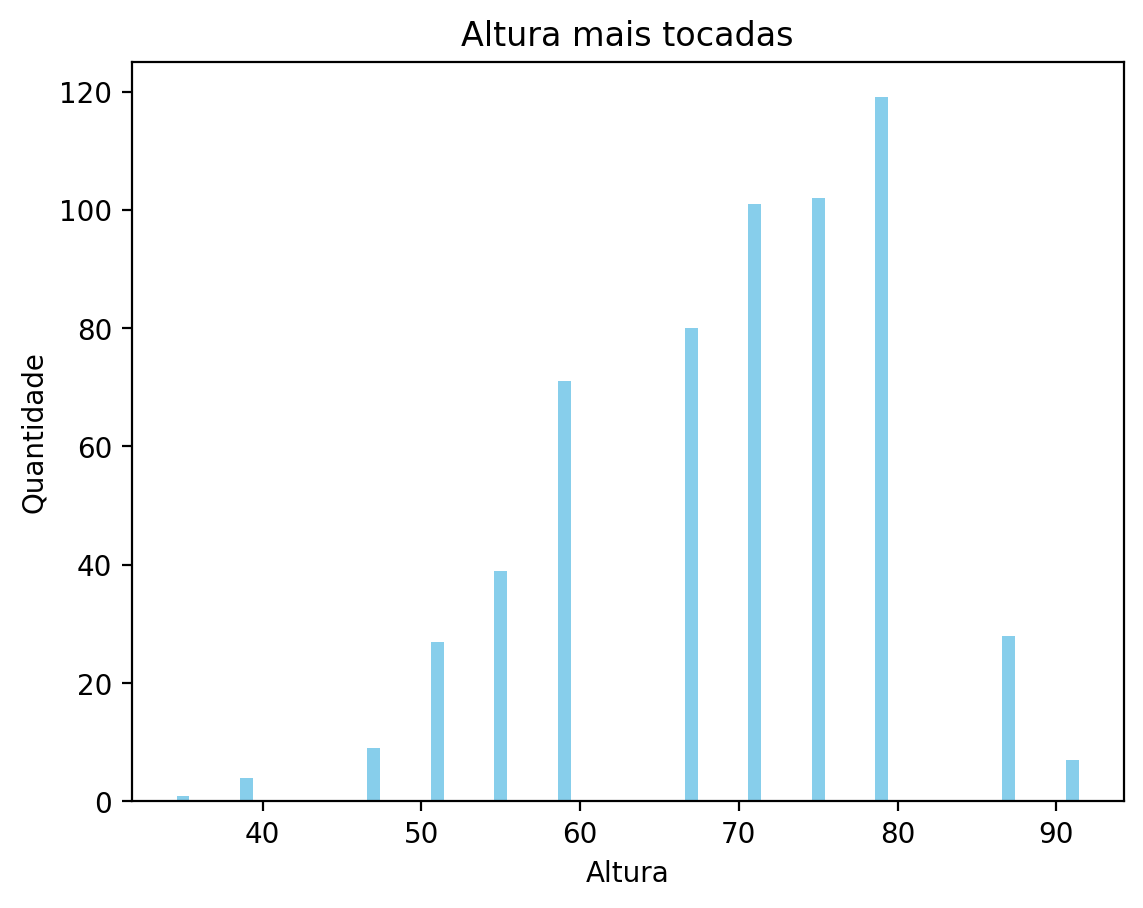


 
 

Quantidade compassos: 45


In [75]:
counter_notes(midi.tokens)